# Project - Social media addiction analysis

Course: Python for Data Science (DSBA), 2025/2026.

Authors: Mitricheva Anna and Romanovskaia Eva, group 251.

## Abstract

We looked at 10000 social media users and found that the amount of time spent on social media is the key factor thet affects the addiction score.

Shortly, TikTok is slightly more connected to addiction than Instagram. Age and sleep, surprisingly, do not seem to matter at all. 

## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler
from scipy import stats

pink = "#D98AA0"
mauve = "#C98BAE"
plum = "#9B6A8F"
beige = "#E4D2B8"
taupe = "#CBB293"
cream = "#FBF3EC"
ink = "#6E4B5E"
palette = ["#E7A6B0", "#D98AA0", "#C98BAE", "#E4D2B8", "#CBB293", "#9B6A8F"]

sns.set_theme(style="whitegrid")
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams["figure.facecolor"] = cream
plt.rcParams["axes.facecolor"] = cream
plt.rcParams["savefig.facecolor"] = cream
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

## Data

Dataset is from https://www.kaggle.com/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060?select=Cover_Global_Tiktok_Instagram_Addiction_%282015-2060%29.png

In [4]:
df = pd.read_csv("data/data.csv")
print("Rows:", df.shape[0], "Columns:", df.shape[1])
df.head()

Rows: 10000 Columns: 23


,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,instagram_minutes_daily,night_usage_ratio,scroll_velocity,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.895513,64.347080,0.312067,0.310389,64.762693,242.853130,27.395222,0.260955,2.607246,69.981792,77.479304,27.024835,60.044856,6.561778,7.912360,100.0,40.460626,63.512418,High
1,2,Netherlands,23,2035,57.950292,76.257045,0.460320,0.293134,37.592646,98.599951,155.167494,0.963487,4.154875,56.862382,78.852713,25.376744,81.769114,9.400197,2.292106,100.0,79.424028,62.688372,High
2,3,Laos,26,2060,40.325805,55.846514,0.893658,0.183055,22.589595,127.221573,69.902284,0.961405,2.791170,41.817693,83.573012,19.712386,99.613065,7.810417,2.308761,100.0,88.262729,59.856193,High
3,4,Bulgaria,50,2046,43.838044,28.390576,0.661523,0.155038,57.093084,140.528514,58.219387,0.685945,3.952342,70.811984,83.437675,19.874790,86.935944,7.020033,4.512440,100.0,70.905771,59.937395,High
4,5,Zambia,24,2045,43.749943,81.413755,0.275186,0.457115,57.653485,187.748696,148.328575,0.716873,2.426045,71.990949,71.993561,33.607727,45.275020,7.900621,4.265014,100.0,51.312439,66.803864,High


The main fields we use: 

1. tiktok_minutes_daily and instagram_minutes_daily — how many minutes per day a person spends on each app
2. night_usage_ratio — what share of their usage happens at night, from 0 to 1
3. attention_span_score — a measure of attention span
4. dopamine_dependency_score — how dependent the user is on dopamine hits
5. sleep_hours — how many hours they sleep
6. age, country, year — basic information about who the user is
7. addiction_score — the numeric addiction score
8. addiction_level — the addiction level: Low, Medium, High or Severe

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   country                      10000 non-null  object 
 2   age                          10000 non-null  int64  
 3   year                         10000 non-null  int64  
 4   internet_penetration         10000 non-null  float64
 5   mental_health_support_index  10000 non-null  float64
 6   gdp_index                    10000 non-null  float64
 7   youth_population_ratio       10000 non-null  float64
 8   baseline_addiction_pressure  10000 non-null  float64
 9   tiktok_minutes_daily         10000 non-null  float64
 10  instagram_minutes_daily      10000 non-null  float64
 11  night_usage_ratio            10000 non-null  float64
 12  scroll_velocity              10000 non-null  float64
 13  addiction_pressur

In [6]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Levels:", df["addiction_level"].unique().tolist())
print("Age from", df["age"].min(), "to", df["age"].max())
print("Year from", df["year"].min(), "to", df["year"].max())

Missing values: 0
Duplicate rows: 0
Levels: ['High', 'Medium', 'Low', 'Severe']
Age from 13 to 59
Year from 2015 to 2060


## Description

Looking at the details: 

In [8]:
num_fields = ["tiktok_minutes_daily", "instagram_minutes_daily", "sleep_hours", "addiction_score", "night_usage_ratio", "attention_span_score"]
desc = df[num_fields].describe().T
desc["median"] = df[num_fields].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,75%,max
tiktok_minutes_daily,10000.0,120.92,120.42,58.32,0.00,79.61,161.26,356.31
instagram_minutes_daily,10000.0,100.11,99.61,49.32,0.00,66.10,133.42,277.10
sleep_hours,10000.0,7.00,6.99,1.46,3.00,5.99,8.04,10.00
addiction_score,10000.0,58.55,61.00,9.27,4.14,57.96,63.68,75.14
night_usage_ratio,10000.0,0.50,0.50,0.29,0.00,0.26,0.75,1.00
attention_span_score,10000.0,81.58,81.67,6.42,58.11,77.19,86.04,100.00


In [9]:
for c in num_fields:
    s = df[c]
    print(c, ": mean - ", round(s.mean(), 2), ", median - ", round(s.median(), 2), ", std - ", round(s.std(), 2))

tiktok_minutes_daily : mean -  120.92 , median -  120.42 , std -  58.32
instagram_minutes_daily : mean -  100.11 , median -  99.61 , std -  49.32
sleep_hours : mean -  7.0 , median -  6.99 , std -  1.46
addiction_score : mean -  58.55 , median -  61.0 , std -  9.27
night_usage_ratio : mean -  0.5 , median -  0.5 , std -  0.29
attention_span_score : mean -  81.58 , median -  81.67 , std -  6.42


On average users spend about 121 minutes a day on TikTok and about 100 on Instagram. They sleep around 7 hours and the addiction score is around 58.

## Data cleanup

Our data is already clean, so we just showed it.

In [10]:
data = df.copy()
data["addiction_level"] = pd.Categorical(data["addiction_level"], categories=["Low", "Medium", "High", "Severe"], ordered=True)
data = data.drop(columns=["user_id"])
print("Missing values:", int(data.isna().sum().sum()))
print("Duplicates:", int(data.duplicated().sum()))
print("Shape:", data.shape)

Missing values: 0
Duplicates: 0
Shape: (10000, 22)


## Data transfornation

New columns:

1. total_minutes — tiktok_minutes_daily plus instagram_minutes_daily
2. daily_hours — total_minutes divided by 60
3. tiktok_share — tiktok_minutes_daily divided by total_minutes
4. night_minutes — total_minutes multiplied by night_usage_ratio
5. age_group — age split into three groups: under 25, 25 to 35, and over 35
6. heavy_user — equals 1 if total time is above the median, otherwise 0
7. level_num — addiction level converted to a number from 1 (Low) to 4 (Severe)

In [11]:
data["total_minutes"] = data["tiktok_minutes_daily"] + data["instagram_minutes_daily"]
data["daily_hours"] = data["total_minutes"] / 60
data["tiktok_share"] = data["tiktok_minutes_daily"] / data["total_minutes"].replace(0, np.nan)
data["night_minutes"] = data["total_minutes"] * data["night_usage_ratio"]
data["age_group"] = pd.cut(data["age"], bins=[0, 25, 35, 200], labels=["<25", "25-35", "35+"])
data["heavy_user"] = (data["total_minutes"] > data["total_minutes"].median()).astype(int)
data["level_num"] = data["addiction_level"].cat.codes + 1
data[["total_minutes", "daily_hours", "tiktok_share", "night_minutes", "age_group", "heavy_user", "level_num"]].head()

,total_minutes,daily_hours,tiktok_share,night_minutes,age_group,heavy_user,level_num
0,270.248352,4.504139,0.898629,70.522647,35+,1,3
1,253.767444,4.229457,0.388545,244.501578,<25,1,3
2,197.123856,3.285398,0.645389,189.515847,25-35,0,3
3,198.747901,3.312465,0.707069,136.330126,35+,0,3
4,336.077271,5.601288,0.558647,240.924796,<25,1,3


## Normalization

The numeric fields are on very different scales (minutes go into the hundreds while ratios stay between 0 and 1). To make them comparable we standardize the columns to mean 0 and standard deviation 1 and keep the original columns for the readable plots.

Honestly, we expect more daily time to go with a higher addiction score, and TikTok to matter a bit more than Instagram. We check the correlations and then fit a standardized linear regression.

In [12]:
scaled_cols = ["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes", "night_minutes", "sleep_hours", "addiction_score"]
for c in scaled_cols:
    data[c] = (data[c] - data[c].mean()) / data[c].std()
data[[c for c in scaled_cols]].describe().round(2).T[["mean", "std", "min", "max"]]

,mean,std,min,max
tiktok_minutes_daily,0.0,1.0,-2.07,4.04
instagram_minutes_daily,0.0,1.0,-2.03,3.59
total_minutes,0.0,1.0,-2.87,3.66
night_minutes,-0.0,1.0,-1.44,4.29
sleep_hours,0.0,1.0,-2.73,2.05
addiction_score,0.0,1.0,-5.87,1.79


## Graphs

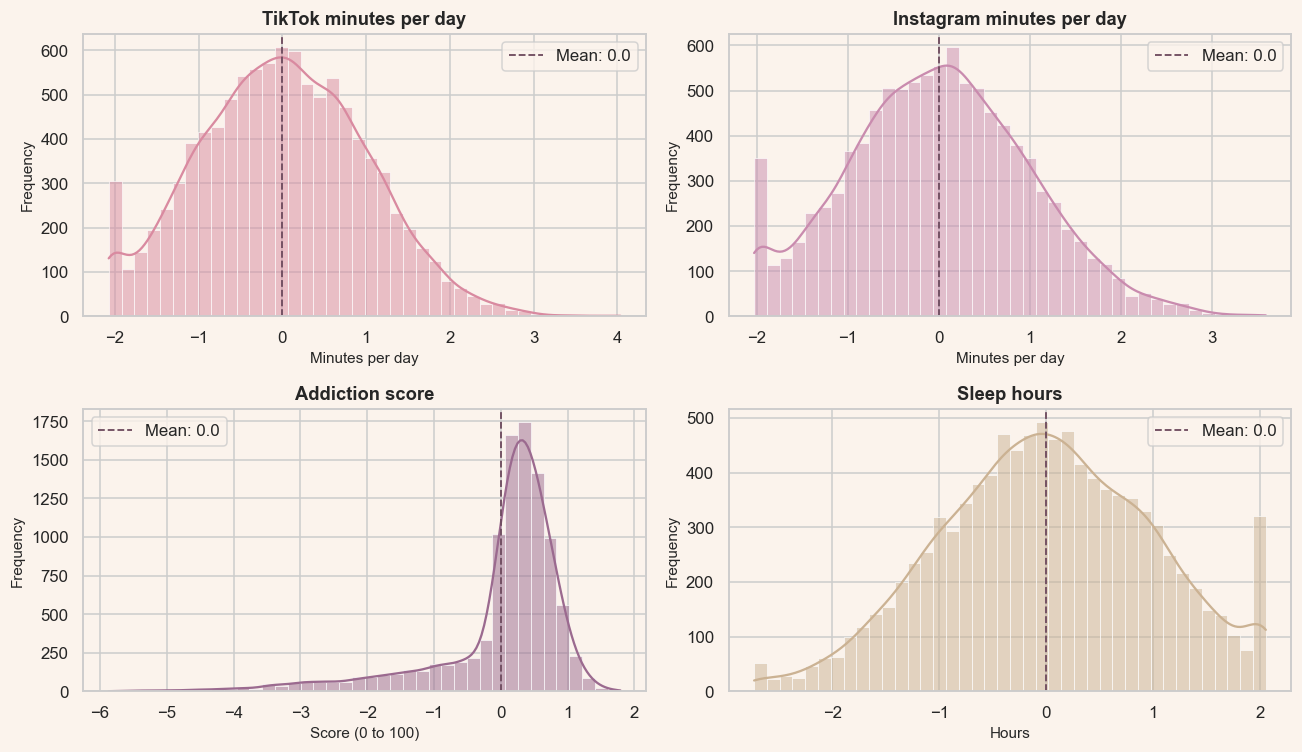

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
s = [("tiktok_minutes_daily", "TikTok minutes per day", pink, "Minutes per day"), ("instagram_minutes_daily", "Instagram minutes per day", mauve, "Minutes per day"), ("addiction_score", "Addiction score", plum, "Score (0 to 100)"), ("sleep_hours", "Sleep hours", taupe, "Hours")]
for ax, (col, title, color, xlabel) in zip(axes.flat, s):
    sns.histplot(data[col], bins=40, kde=True, color=color, ax=ax, edgecolor="white", linewidth=0.4)
    ax.axvline(data[col].mean(), color=ink, ls="--", lw=1.2, label=f"Mean: {data[col].mean():.1f}")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend()

plt.tight_layout()
plt.tight_layout()
plt.show()

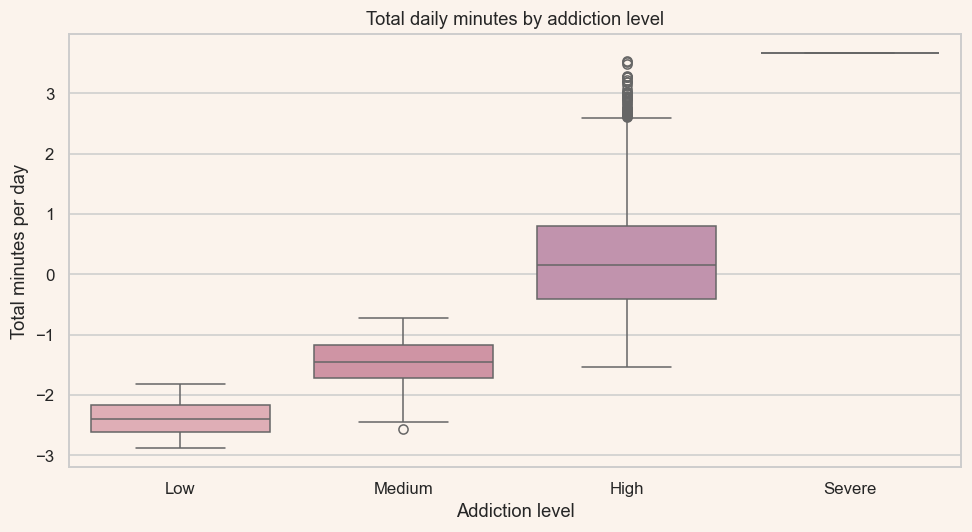

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="addiction_level", y="total_minutes", order=["Low", "Medium", "High", "Severe"], hue="addiction_level", palette=palette[:4], legend=False)
plt.title("Total daily minutes by addiction level")
plt.xlabel("Addiction level")
plt.ylabel("Total minutes per day")
plt.tight_layout()
plt.show()

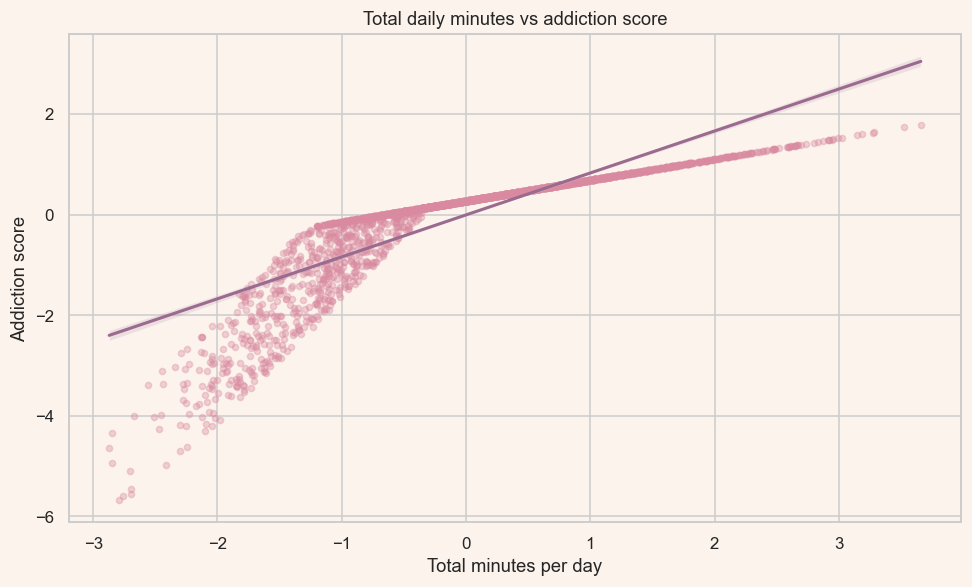

In [16]:
sample = data.sample(3000, random_state=1)
plt.figure(figsize=(9, 5.5))
sns.regplot(data=sample, x="total_minutes", y="addiction_score", scatter_kws={"alpha": 0.35, "s": 16, "color": pink}, line_kws={"color": plum, "lw": 2})
plt.title("Total daily minutes vs addiction score")
plt.xlabel("Total minutes per day")
plt.ylabel("Addiction score")
plt.tight_layout()
plt.show()

The box plot shows total minutes rising sharply with the addiction level, and the scatter shows a clear upward trend between minutes and the score.

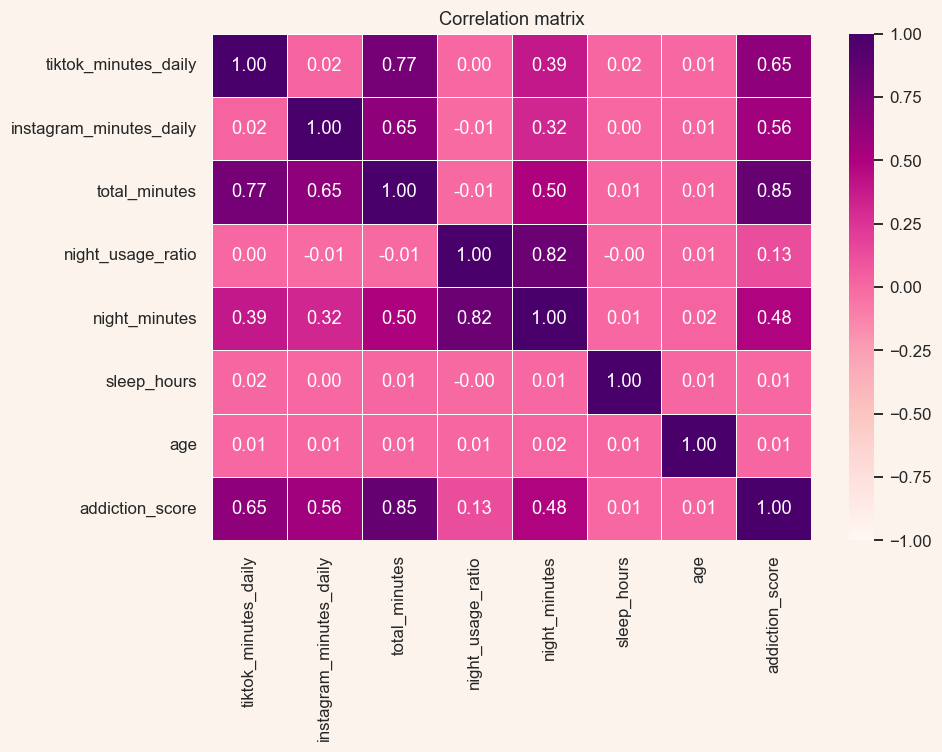

In [17]:
corr_cols = ["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes", "night_usage_ratio", "night_minutes", "sleep_hours", "age", "addiction_score"]
plt.figure(figsize=(9, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdPu", vmin=-1, vmax=1, linewidths=0.5, linecolor="white")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

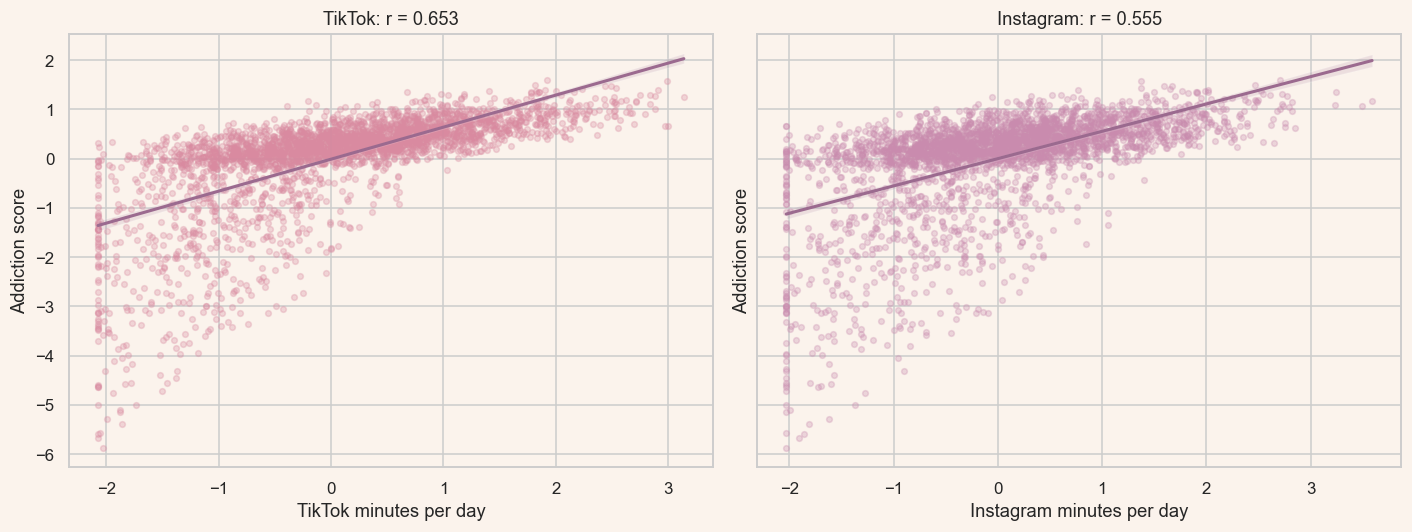

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, col, title, color in zip(axes, ["tiktok_minutes_daily", "instagram_minutes_daily"], ["TikTok", "Instagram"], [pink, mauve]):
    s = data.sample(3000, random_state=2)
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax, scatter_kws={"alpha": 0.3, "s": 14, "color": color}, line_kws={"color": plum, "lw": 2})
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(f"{title}: r = {round(r, 3)}")
    ax.set_xlabel(f"{title} minutes per day")
    ax.set_ylabel("Addiction score")

plt.tight_layout()
plt.show()

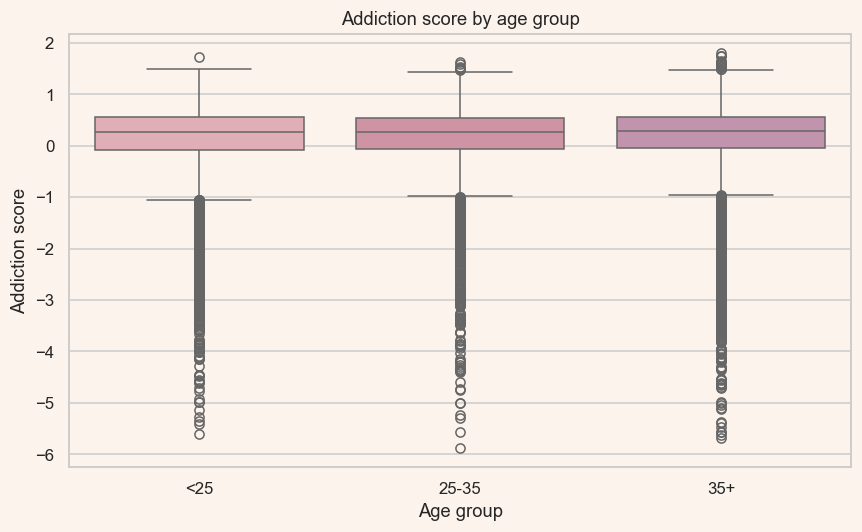

age_group
<25     -0.02
25-35   -0.01
35+      0.01
Name: addiction_score, dtype: float64


In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="age_group", y="addiction_score", order=["<25", "25-35", "35+"], hue="age_group", palette=palette[:3], legend=False)
plt.title("Addiction score by age group")
plt.xlabel("Age group")
plt.ylabel("Addiction score")
plt.tight_layout()
plt.show()

print(data.groupby("age_group", observed=True)["addiction_score"].mean().round(2))

In [21]:
profile = data.groupby("addiction_level", observed=True).agg(n=("addiction_level", "size"), total_minutes=("total_minutes", "mean"), night_minutes=("night_minutes", "mean"), sleep_hours=("sleep_hours", "mean"), age=("age", "mean")).round(1)
profile

,n,total_minutes,night_minutes,sleep_hours,age
addiction_level,,,,,
Low,121,-2.4,-1.3,0.2,34.0
Medium,1198,-1.5,-0.9,-0.1,35.7
High,8680,0.2,0.1,0.0,35.8
Severe,1,3.7,3.7,0.2,37.0


The correlation matrix makes the picture clear: the addiction score is strongly linked to total minutes and to the TikTok and Instagram minutes, while sleep and age do not. TikTok has a higher correlation than Instagram. The age groups have almost the same average score, and the profile table shows that higher addiction levels mostly mean a lot more dminutes spent.

## Hypotheses


### 1. Time drives addiction, and TikTok matters more than Instagram


In [23]:
r_tt, p_tt = stats.pearsonr(data["tiktok_minutes_daily"], data["addiction_score"])
r_ig, p_ig = stats.pearsonr(data["instagram_minutes_daily"], data["addiction_score"])
r_tot, p_tot = stats.pearsonr(data["total_minutes"], data["addiction_score"])
print("TikTok r =", round(r_tt, 3), "p =", p_tt)
print("Instagram r =", round(r_ig, 3), "p =", p_ig)
print("Total r =", round(r_tot, 3), "p =", p_tot)
X = np.column_stack([np.ones(len(data)), data["tiktok_minutes_daily_z"], data["instagram_minutes_daily_z"]])
beta = np.linalg.lstsq(X, data["addiction_score_z"].values, rcond=None)[0]
print("Standardized coefficients: TikTok =", round(beta[1], 3), "Instagram =", round(beta[2], 3))

TikTok r = 0.653 p = 0.0
Instagram r = 0.555 p = 0.0
Total r = 0.85 p = 0.0


KeyError: 'tiktok_minutes_daily_z'

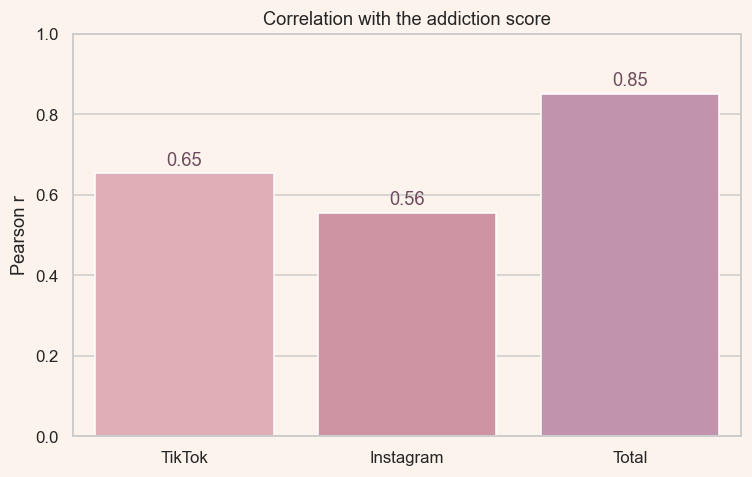

In [24]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x=['TikTok', 'Instagram', 'Total'], y=[r_tt, r_ig, r_tot], hue=['TikTok', 'Instagram', 'Total'], palette=palette[:3], legend=False)
plt.title("Correlation with the addiction score")
plt.ylabel("Pearson r")
plt.ylim(0, 1)
for i, v in enumerate([r_tt, r_ig, r_tot]):
    plt.text(i, v + 0.02, round(v, 2), ha="center", color=ink)
plt.tight_layout()
plt.show()

The hypothesis holds. Both apps have a strong and significant correlation with the addiction score (p well below 0.05), the combined time is even more - with r around 0.85, and the regression gives TikTok a larger coefficient than Instagram. So time clearly drives the score and TikTok matters a bit more, which we can also see in the two scatter plots above.

### 2. Age and sleep are not related to the addiction score

A common idea is that young people or people who sleep less are more addicted. We did not expect the opposite to show in this data, that age and sleep have no real link to the score. We test both correlations and compare the youngest users (under 25) with the oldest (over 35).

In [28]:
r_age, p_age = stats.pearsonr(data["age"], data["addiction_score"])
r_sleep, p_sleep = stats.pearsonr(data["sleep_hours"], data["addiction_score"])
young = data[data["age"] < 25]["addiction_score"]
adult = data[data["age"] >= 35]["addiction_score"]
t, p_grp = stats.ttest_ind(young, adult, equal_var=False)
print("Age r =", round(r_age, 3), "p =", round(p_age, 3))
print("Sleep r =", round(r_sleep, 3), "p =", round(p_sleep, 3))
print("Mean score, young:", round(young.mean(), 2), "adults:", round(adult.mean(), 2))
print("t-test young vs adults: t =", round(t, 2), "p =", round(p_grp, 3))

Age r = 0.01 p = 0.295
Sleep r = 0.007 p = 0.498
Mean score, young: -0.02 adults: 0.01
t-test young vs adults: t = -1.3 p = 0.194


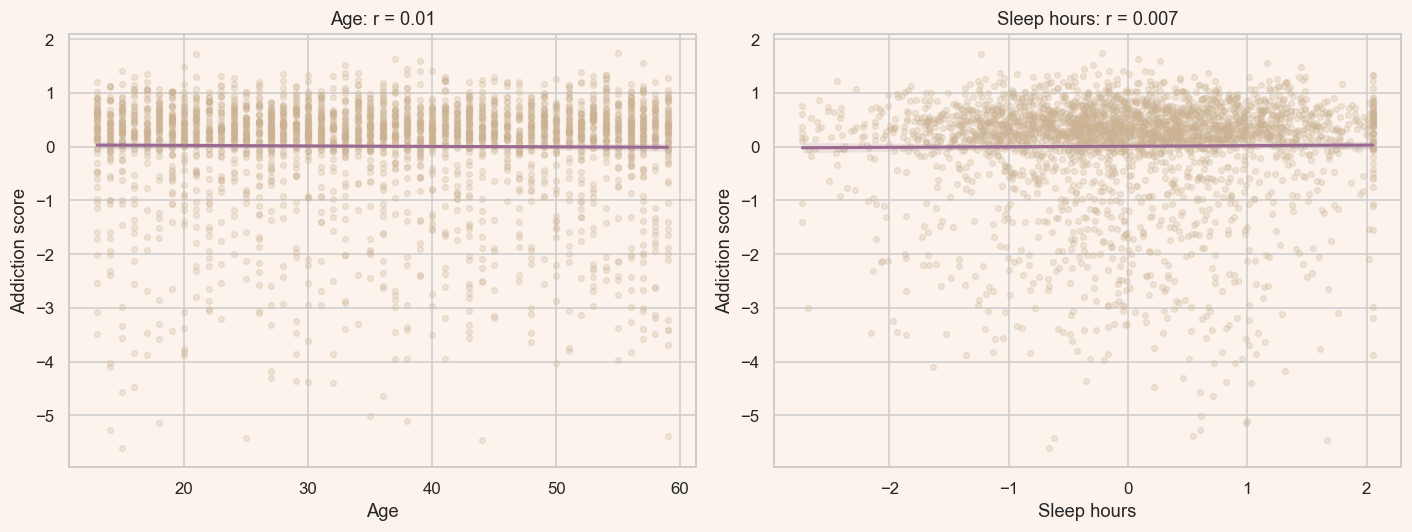

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
s = data.sample(3000, random_state=4)
for ax, col, title in zip(axes, ["age", "sleep_hours"], ["Age", "Sleep hours"]):
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax, scatter_kws={"alpha": 0.25, "s": 14, "color": taupe}, line_kws={"color": plum, "lw": 2})
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(f"{title}: r = {round(r, 3)}")
    ax.set_xlabel(title)
    ax.set_ylabel("Addiction score")
plt.tight_layout()
plt.show()

## Conclusion

1. The time spent on social media is the main thing linked to the addiction score, with the total daily minutes reaching a correlation of about 0.85.
2. TikTok is connected to the score a little more than Instagram, both in the correlations and in the regression.
3. Age and sleep are not related to the addiction score at all, which is a clear result against the usual assumption.
4. Higher addiction levels mostly mean a lot more daily and night minutes, while sleep and age do not really matter here.

What stands over the facts and graphs is that if we want to understand a person's addiction score in this data, it will be useful to know how much and how late they scroll, especially on TikTok, and not their age or how long they sleep. The difference between age groups is smaller than we initially assumed.


P.S.

One limitation of the dataset is that it contains self-reported behaviour, which may not always be fully accurate. The dataset also represents a specific sample of users, therefore the results should not be generalized to all social media users.